# 第 2 课：Frame、Window、Hop

这一课回答三个问题：为什么要把语音切成小段？相邻小段为什么重叠？为什么每一帧还要乘窗函数？

学习顺序：真实波形 → frame → hop → overlap → window → 频谱泄漏预览。FFT 的具体原理留到下一课。

<!-- course-upgrade-v2 -->
## 学习导航

| 项目 | 内容 |
|---|---|
| 所属阶段 | 声音与声学特征 |
| 建议投入 | 2～4 小时，可分 2～3 次完成 |
| 前置要求 | 完成第 1 课；如果前测低于 2/3，先回看上一课小结 |
| 本课核心 | frame/window、hop、窗函数与频谱泄漏 |
| 完成标准 | 能口头解释核心概念；独立完成强化题；从空白重写核心函数 |

高效顺序：**先回答前测 → 预测代码结果 → 再运行 → 修改一个变量 → 关闭答案复现 → 次日回忆。**


<!-- course-upgrade-v2 -->
## 课前诊断（先不要运行代码）

1. 分别用一句话解释：frame/window、hop、窗函数与频谱泄漏。
2. 画出这三个概念之间的输入—输出关系。
3. 写下你最不确定的一点，并给出一个暂时猜测。

自评：答对 0～1 题先复习前置课；答对 2 题可以正常学习；3 题都能讲清楚则直接挑战代码和迁移题。


## 0. 导入库并读取真实语音

样本来自 Free Spoken Digit Dataset，内容是一位说话者读数字 0。原始采样率是 8 kHz，本课先保持原采样率，避免把分帧概念和重采样混在一起。

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import ipywidgets as widgets

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
audio_path = ROOT / 'data' / '0_jackson_0.wav'
audio, sr = sf.read(audio_path)
if audio.ndim > 1:
    audio = audio.mean(axis=1)
duration = len(audio) / sr
print(f'采样率: {sr} Hz')
print(f'采样点数: {len(audio)}')
print(f'时长: {duration:.3f} 秒')

采样率: 8000 Hz
采样点数: 5148
时长: 0.643 秒


G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 35821 (\N{CJK UNIFIED IDEOGRAPH-8BED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

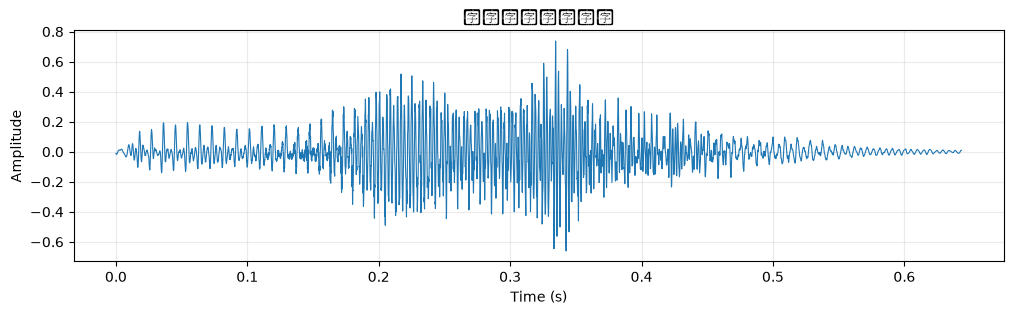

In [2]:
time = np.arange(len(audio)) / sr
plt.figure(figsize=(12, 3))
plt.plot(time, audio, linewidth=0.8)
plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
plt.title('整段真实语音波形')
plt.grid(alpha=0.25); plt.show()

### 热身题

1. 这段音频大约多长？
2. 波形在哪个时间区域振幅最大？
3. 只看整段波形，你能准确知道其中有哪些频率吗？

第 3 题的答案应当是不能，这正是后续要分帧分析的原因。

## 1. Frame：把长语音切成短片段

语音一直在变化，但在很短的时间内可以近似认为发音状态比较稳定，这叫短时平稳。常见帧长是 20～30 ms。

毫秒转换成采样点：

$$N_{frame}=f_s\times frame\_ms/1000$$

本音频是 8 kHz，因此 25 ms 一帧包含 $8000\times0.025=200$ 个采样点。若音频是 16 kHz，则相同 25 ms 包含 400 点。

C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\3154100473.py:15: UserWarning: Glyph 25972 (\N{CJK UNIFIED IDEOGRAPH-6574}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\3154100473.py:15: UserWarning: Glyph 27573 (\N{CJK UNIFIED IDEOGRAPH-6BB5}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\3154100473.py:15: UserWarning: Glyph 35821 (\N{CJK UNIFIED IDEOGRAPH-8BED}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\3154100473.py:15: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\3154100473.py:15: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_111

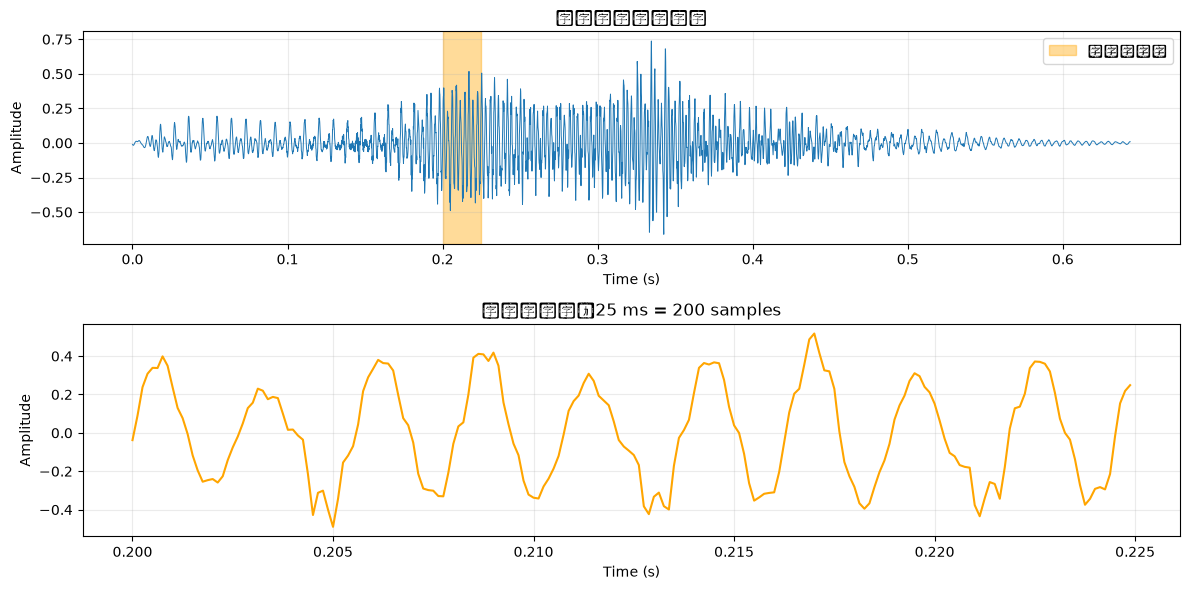

In [3]:
frame_ms = 25
frame_size = round(sr * frame_ms / 1000)
start_time = 0.20
start = round(start_time * sr)
frame = audio[start:start + frame_size]
frame_time = np.arange(len(frame)) / sr + start_time

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(time, audio, linewidth=0.7)
axes[0].axvspan(start_time, start_time + frame_ms/1000, color='orange', alpha=0.4, label='选中的一帧')
axes[0].legend(); axes[0].set_title('整段语音中的一帧')
axes[1].plot(frame_time, frame, color='orange')
axes[1].set_title(f'放大这一帧：{frame_ms} ms = {frame_size} samples')
for ax in axes: ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### 练习 1

1. 16 kHz 音频的 20 ms 一帧有多少点？
2. 16 kHz 音频的 30 ms 一帧有多少点？
3. 8 kHz 音频的 25 ms 一帧为什么是 200 点，而不是 400 点？

参考答案：320；480；因为相同时间内，8 kHz 的每秒采样次数只有 16 kHz 的一半。

## 2. Hop：每次向前移动多少

如果帧长是 25 ms，帧移 hop 是 10 ms：第 1 帧覆盖 0～25 ms，第 2 帧覆盖 10～35 ms。两帧重叠 15 ms。

$$overlap=frame\_length-hop\_length$$

hop 决定多长时间产生一次新特征。10 ms hop 意味着一秒大约产生 100 帧。

In [4]:
def draw_frames(frame_ms=25, hop_ms=10, number_of_frames=5):
    y = np.zeros(number_of_frames)
    plt.figure(figsize=(11, 3))
    for i in range(number_of_frames):
        start_ms = i * hop_ms
        end_ms = start_ms + frame_ms
        plt.plot([start_ms, end_ms], [i, i], linewidth=10, alpha=0.65)
        plt.text(start_ms, i + 0.18, f'{start_ms}–{end_ms} ms')
    plt.xlabel('Time (ms)'); plt.ylabel('Frame index')
    plt.title(f'frame={frame_ms} ms, hop={hop_ms} ms, overlap={max(0, frame_ms-hop_ms)} ms')
    plt.grid(axis='x', alpha=0.25); plt.show()

widgets.interact(
    draw_frames,
    frame_ms=widgets.IntSlider(value=25, min=10, max=50, step=5, description='帧长'),
    hop_ms=widgets.IntSlider(value=10, min=5, max=50, step=5, description='帧移'),
    number_of_frames=widgets.IntSlider(value=5, min=3, max=10, step=1, description='帧数')
)

interactive(children=(IntSlider(value=25, description='帧长', max=50, min=10, step=5), IntSlider(value=10, descr…

<function __main__.draw_frames(frame_ms=25, hop_ms=10, number_of_frames=5)>

### 交互题 A

1. 设置 frame=25 ms、hop=10 ms，重叠多少 ms？
2. 设置 frame=40 ms、hop=10 ms，重叠多少 ms？
3. 设置 frame=20 ms、hop=30 ms，会出现什么？相邻帧之间是否遗漏了一段信号？
4. 如果 hop=10 ms，1 秒大约有多少个帧起点？

## 3. 在真实语音上观察重叠帧

下面用彩色阴影标出前几帧。重叠不是重复录音，而是分析时重复使用一部分采样点。

In [5]:
def draw_audio_frames(frame_ms=25, hop_ms=10):
    frame_n = round(sr * frame_ms / 1000)
    hop_n = round(sr * hop_ms / 1000)
    plt.figure(figsize=(12, 3))
    plt.plot(time[:round(0.1*sr)], audio[:round(0.1*sr)], color='black', linewidth=0.7)
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    for i in range(4):
        start = i * hop_n / sr
        end = (i * hop_n + frame_n) / sr
        plt.axvspan(start, end, alpha=0.18, color=colors[i], label=f'frame {i}')
    plt.xlabel('Time (s)'); plt.ylabel('Amplitude')
    plt.title(f'真实语音：frame={frame_ms} ms, hop={hop_ms} ms')
    plt.legend(); plt.grid(alpha=0.25); plt.show()

widgets.interact(
    draw_audio_frames,
    frame_ms=widgets.IntSlider(value=25, min=10, max=50, step=5, description='帧长'),
    hop_ms=widgets.IntSlider(value=10, min=5, max=40, step=5, description='帧移')
)

interactive(children=(IntSlider(value=25, description='帧长', max=50, min=10, step=5), IntSlider(value=10, descr…

<function __main__.draw_audio_frames(frame_ms=25, hop_ms=10)>

## 4. Window：为什么不能直接截断

截取一帧相当于让帧外的数据突然变成 0。如果帧首尾不能自然衔接，这个突然跳变会制造额外的频率成分，称为频谱泄漏。

矩形窗等于什么都不衰减；Hann 窗把两端平滑压到 0。

C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\2918563104.py:13: UserWarning: Glyph 20004 (\N{CJK UNIFIED IDEOGRAPH-4E24}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\2918563104.py:13: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\2918563104.py:13: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\2918563104.py:13: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_11180\2918563104.py:13: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\zjj\AppData\Local\Temp\ipykernel_111

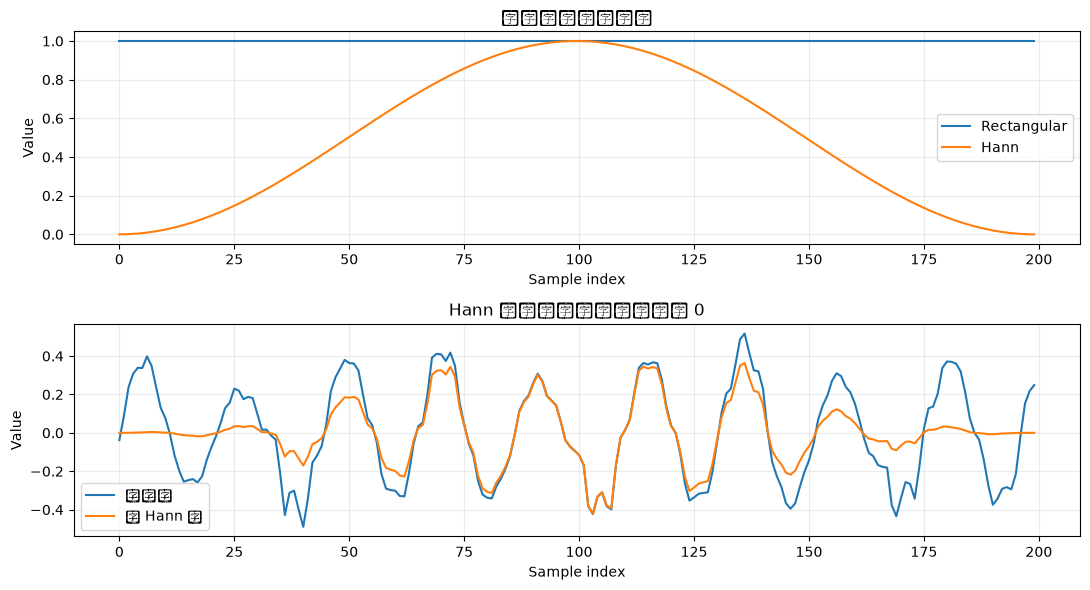

In [6]:
n = 200
rectangular = np.ones(n)
hann = np.hanning(n)
fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(rectangular, label='Rectangular')
axes[0].plot(hann, label='Hann')
axes[0].set_title('两种窗函数的权重'); axes[0].legend()
example = audio[start:start+n]
axes[1].plot(example, label='原始帧')
axes[1].plot(example*hann, label='乘 Hann 后')
axes[1].set_title('Hann 窗让帧的两端平滑降到 0'); axes[1].legend()
for ax in axes: ax.set_xlabel('Sample index'); ax.set_ylabel('Value'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

### 重要提醒

窗函数不是说‘两端的数据没用’，而是在进行每帧频谱分析时降低边界突变。由于帧彼此重叠，一帧边缘的采样点通常会在邻近帧的中间位置再次被较大权重使用。

G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23792 (\N{CJK UNIFIED IDEOGRAPH-5CF0}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 31245 (\N{CJK UNIFIED IDEOGRAPH-7A0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 23485 (\N{CJK UNIFIED IDEOGRAPH-5BBD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
G:\learn_asr\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65292 (\N{FULLWIDTH COMMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

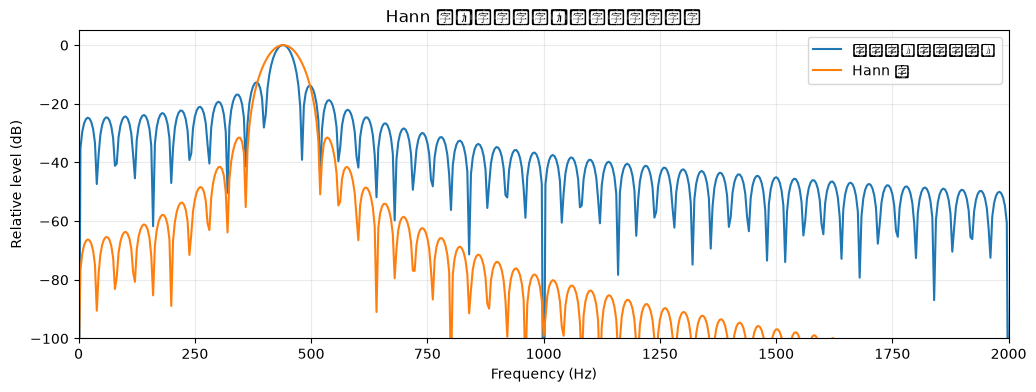

In [7]:
# 用 440 Hz 纯音直观看频谱泄漏。这里先把 FFT 当作‘把信号拆成频率’的工具。
tone_n = 400
tone_t = np.arange(tone_n) / 16_000
tone = np.sin(2*np.pi*440*tone_t)
n_fft = 4096
freqs = np.fft.rfftfreq(n_fft, 1/16_000)

def relative_db(x):
    magnitude = np.abs(np.fft.rfft(x, n=n_fft))
    return 20*np.log10(np.maximum(magnitude/magnitude.max(), 1e-8))

plt.figure(figsize=(12, 4))
plt.plot(freqs, relative_db(tone), label='矩形窗（直接截断）')
plt.plot(freqs, relative_db(tone*np.hanning(tone_n)), label='Hann 窗')
plt.xlim(0, 2000); plt.ylim(-100, 5)
plt.xlabel('Frequency (Hz)'); plt.ylabel('Relative level (dB)')
plt.title('Hann 窗：主峰稍宽，但远处泄漏更低')
plt.legend(); plt.grid(alpha=0.25); plt.show()

### 练习 2：看图题

1. 哪条曲线的主峰更窄？
2. 哪条曲线远离 440 Hz 后的旁瓣更低？
3. Hann 窗做了什么取舍？

参考答案：矩形窗主峰更窄；Hann 窗旁瓣更低；它用稍宽的主峰换取更少的远处泄漏。

## 5. 综合计算器

拖动参数，观察采样点数量、重叠长度和大约每秒帧数。

In [8]:
def parameter_calculator(sample_rate=16000, frame_ms=25, hop_ms=10):
    frame_samples = round(sample_rate*frame_ms/1000)
    hop_samples = round(sample_rate*hop_ms/1000)
    overlap_ms = frame_ms-hop_ms
    print(f'一帧采样点: {frame_samples}')
    print(f'每次移动采样点: {hop_samples}')
    print(f'重叠时间: {overlap_ms} ms')
    print(f'每秒大约产生: {1000/hop_ms:.1f} 帧')

widgets.interact(
    parameter_calculator,
    sample_rate=widgets.Dropdown(options=[8000,16000,44100,48000], value=16000, description='采样率'),
    frame_ms=widgets.IntSlider(value=25,min=10,max=50,step=5,description='帧长'),
    hop_ms=widgets.IntSlider(value=10,min=5,max=30,step=5,description='帧移')
)

interactive(children=(Dropdown(description='采样率', index=1, options=(8000, 16000, 44100, 48000), value=16000), …

<function __main__.parameter_calculator(sample_rate=16000, frame_ms=25, hop_ms=10)>

## 本课测试（先不要看答案）

1. 16 kHz、25 ms 的一帧有多少采样点？
2. 16 kHz、10 ms 的 hop 有多少采样点？
3. frame=25 ms、hop=10 ms，重叠多少 ms？
4. 为什么语音不能只做一次整段频率分析？
5. hop 越小，每秒得到的帧数更多还是更少？计算 5 ms hop 每秒约多少帧。
6. 矩形窗和 Hann 窗各有什么优缺点？
7. 为什么窗函数和帧重叠经常一起使用？

答案：1 400；2 160；3 15 ms；4 语音频率结构随时间变化；5 更多，约 200 帧；6 矩形窗主峰窄但泄漏大，Hann 主峰稍宽但泄漏小；7 一帧边缘被衰减的信息可在相邻帧中间再次得到较高权重。

## 小结

| 参数 | 它控制什么 | 常见值 |
|---|---|---|
| frame length | 一次观察多长时间 | 25 ms |
| hop length | 多久产生一个新特征 | 10 ms |
| overlap | 相邻帧重复使用多少时间 | 15 ms |
| window | 降低帧边界造成的频谱泄漏 | Hann/Hamming |

下一课：频率、频谱、DFT 与 FFT。我们会从‘一个纯音为什么在频谱上出现一个峰’开始。

<!-- course-upgrade-v2 -->
## 强化练习：第 2 课专属题库

请先把答案写进新的 Markdown/Code cell，再展开自评标准。

### A. 基础回忆

1. 不看上文，分别定义 `frame/window`、`hop`、`窗函数与频谱泄漏`。
2. 哪一个量/状态是本课最容易在模块边界丢失的？它的单位和 shape 是什么？
3. 本课至少写出两个“看起来能运行，但结果其实错误”的例子。

### B. 预测与推理

4. 场景：**把 hop 从 10 ms 改成 25 ms**。先预测现象，再说明原因，最后给出一项可以验证猜测的指标。
5. 改变本课最关键参数的 0.5×、1×、2×，分别预测准确率、延迟、内存或数值误差怎样变化。
6. 画一张最小数据流图，在每条边标出 dtype、shape、时间单位或概率/代价方向。

### C. 编程与排错

7. 编程任务：**实现不依赖 librosa 的分帧并验证首尾索引**。至少加入正常、边界、错误输入三类测试。
8. 故意制造一个 off-by-one、shape、状态未 reset 或数值稳定性错误；记录错误现象和定位过程。
9. 不看本课实现，从空白 cell 重写最核心函数，并用原实现作数值对照。

### D. 迁移与表达

10. 跨课任务：**说明分帧参数怎样决定 STFT 时间分辨率**。
11. 用 90 秒向没有学过 ASR 的人解释本课；禁止只念术语，必须举一个数字或生活例子。
12. 写出一个生产系统中会监控的指标，以及它异常时优先检查的三处位置。

<details><summary>展开自评标准</summary>

- 每题 0～2 分：0=无法回答；1=方向正确但缺少单位、边界或验证；2=解释完整且能用代码/数字验证。
- 24 分满分：达到 19 分再进入下一课；15～18 分次日重做错题；低于 15 分回看本课图和核心代码。
- 第 4 题必须包含“预测—原因—指标”，第 7～9 题必须真正运行测试，第 10 题必须明确上下游 contract。
- 核心答案至少应正确使用：frame/window、hop、窗函数与频谱泄漏。

</details>


<!-- course-upgrade-v2 -->
## 间隔复习与离场票

### 离场票（现在完成）

- [ ] 我能不用笔记解释 frame/window、hop、窗函数与频谱泄漏。
- [ ] 我能说出本课最常见的错误及其观测现象。
- [ ] 我能从空白重写一个核心函数，并通过至少 3 个测试。
- [ ] 我能说明本课对上一层和下一层接口的影响。

### 复习时间表

- **明天（5 分钟）**：闭卷写出三个核心概念和一个公式/shape。
- **7 天后（15 分钟）**：重做第 4、7、10 题，不运行原答案。
- **30 天后（20 分钟）**：从真实音频或随机张量重新构造一个最小实验。

把错题记录到根目录 `LEARNING_LOG.md`。不要只写“不会”，要写：原判断、证据、正确规则、下次检查动作。
